# Alignment in Large Language Models: From RLHF to DPO

The previous notebook explained how we can efficiently adapt a pretrained LLM with parameter-efficient fine-tuning.

This notebook answers the next important question:

**How do we make a language model behave the way humans actually want?**

Pretraining teaches language. Fine-tuning teaches tasks. Alignment teaches behavior.

## Introduction

A pretrained language model learns patterns from text. An instruction-tuned model learns how to follow task formats. But neither step automatically guarantees that the model will be helpful, honest, safe, or polite.

Without alignment, a language model may generate responses that are harmful, misleading, rude, overconfident, or simply not useful. Alignment methods use human preferences and safety feedback to steer model behavior toward responses people actually want.

In [1]:
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

SEED = 42
np.random.seed(SEED)

plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

## The LLM Training Pipeline

A simplified modern LLM training pipeline often looks like this:

Raw Text → Pretraining → Instruction Fine-Tuning (SFT) → Reward Model → RLHF → Aligned Model

Each stage teaches a different capability.

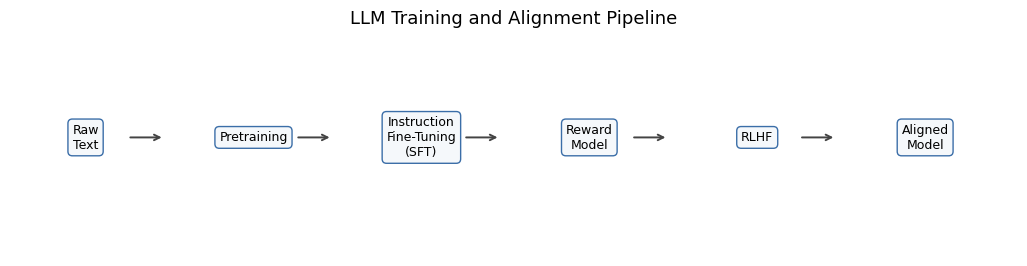

In [2]:
def draw_pipeline(steps, title, color="#3b6ea8", figsize=(13, 2.8)):
    """Draw a horizontal pipeline diagram with matplotlib."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")
    ax.set_xlim(0, len(steps))
    ax.set_ylim(0, 1)

    for idx, step in enumerate(steps):
        ax.text(
            idx + 0.45,
            0.55,
            step,
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="#f5f8fb", edgecolor=color),
            fontsize=9,
        )
        if idx < len(steps) - 1:
            ax.annotate(
                "",
                xy=(idx + 0.92, 0.55),
                xytext=(idx + 0.70, 0.55),
                arrowprops=dict(arrowstyle="->", lw=1.4, color="#444444"),
            )

    ax.set_title(title, fontsize=13, pad=12)
    plt.show()

training_steps = [
    "Raw\nText",
    "Pretraining",
    "Instruction\nFine-Tuning\n(SFT)",
    "Reward\nModel",
    "RLHF",
    "Aligned\nModel",
]

draw_pipeline(training_steps, "LLM Training and Alignment Pipeline")

In [3]:
pipeline_df = pd.DataFrame({
    "stage": ["Pretraining", "Instruction Fine-Tuning", "Reward Model", "RLHF", "Aligned Model"],
    "what it learns": [
        "language patterns and general knowledge",
        "how to respond to instructions",
        "which responses humans prefer",
        "how to optimize behavior using reward feedback",
        "a more helpful and safer response style",
    ],
    "typical data": [
        "large raw text corpora",
        "prompt-response demonstrations",
        "preference comparisons",
        "prompts plus reward scores",
        "evaluation and deployment feedback",
    ],
})

display(pipeline_df)

,stage,what it learns,typical data
0,Pretraining,language patterns and general knowledge,large raw text corpora
1,Instruction Fine-Tuning,how to respond to instructions,prompt-response demonstrations
2,Reward Model,which responses humans prefer,preference comparisons
3,RLHF,how to optimize behavior using reward feedback,prompts plus reward scores
4,Aligned Model,a more helpful and safer response style,evaluation and deployment feedback


## Why Next-Token Prediction Is Not Enough

Next-token prediction can make a model fluent, but fluency is not the same as good behavior.

A response can be factually correct but still rude. It can be confident but misleading. It can answer the literal question while ignoring user safety. It can be technically detailed but not useful for the person asking.

Alignment is necessary because user-facing assistants need more than language modeling. They need preferences, constraints, and judgment.

In [4]:
behavior_examples = pd.DataFrame({
    "situation": [
        "User asks for help fixing a bug",
        "User asks a medical question",
        "User asks about a security incident",
        "User asks for a summary",
    ],
    "fluent but poorly aligned": [
        "This is easy. You clearly forgot the obvious fix.",
        "You definitely have condition X. Take this medication.",
        "Disable all alerts so the noise stops.",
        "Here is a long summary with unsupported details.",
    ],
    "better aligned": [
        "Here are likely causes and a safe debugging path.",
        "I cannot diagnose you, but I can explain general possibilities and suggest professional care.",
        "Preserve logs, rotate credentials if needed, and investigate suspicious access.",
        "Here is a concise summary based only on the provided text.",
    ],
})

display(behavior_examples)

,situation,fluent but poorly aligned,better aligned
0,User asks for help fixing a bug,This is easy. You clearly forgot the obvious fix.,Here are likely causes and a safe debugging path.
1,User asks a medical question,You definitely have condition X. Take this med...,"I cannot diagnose you, but I can explain gener..."
2,User asks about a security incident,Disable all alerts so the noise stops.,"Preserve logs, rotate credentials if needed, a..."
3,User asks for a summary,Here is a long summary with unsupported details.,Here is a concise summary based only on the pr...


## Supervised Fine-Tuning (SFT)

Supervised Fine-Tuning teaches a model to follow instructions using teacher demonstrations.

A typical SFT dataset contains:

- prompt
- high-quality response
- sometimes metadata such as task type, domain, or safety label

SFT is often the first step toward making a pretrained model feel like an assistant.

In [5]:
sft_examples = pd.DataFrame({
    "prompt": [
        "Explain gradient descent in simple terms.",
        "Write a short SQL query to count users by country.",
        "Summarize this support ticket in one sentence.",
    ],
    "teacher_response": [
        "Gradient descent improves a model by taking small steps that reduce prediction error.",
        "SELECT country, COUNT(*) AS user_count FROM users GROUP BY country;",
        "The customer cannot reset their password because the recovery email is not arriving.",
    ],
})

display(sft_examples)

,prompt,teacher_response
0,Explain gradient descent in simple terms.,Gradient descent improves a model by taking sm...
1,Write a short SQL query to count users by coun...,"SELECT country, COUNT(*) AS user_count FROM us..."
2,Summarize this support ticket in one sentence.,The customer cannot reset their password becau...


## Human Preference Data

Preference datasets compare candidate responses.

A human reviewer sees a prompt, Answer A, and Answer B, then chooses which answer is better. The chosen answer is not always the longest or most confident response. It is usually the response that is more helpful, safer, clearer, or better calibrated.

In [6]:
preference_examples = pd.DataFrame({
    "prompt": [
        "How can I make my API more reliable?",
        "I clicked a suspicious link. What should I do?",
        "Explain overfitting to a beginner.",
        "Can you summarize these incident notes?",
    ],
    "answer_a": [
        "Add retries, timeouts, monitoring, and clear error handling.",
        "Ignore it unless something breaks.",
        "Overfitting means the model memorizes training data and performs poorly on new data.",
        "The incident was bad and many things failed, probably due to several causes.",
    ],
    "answer_b": [
        "APIs are complicated, so just use a bigger server.",
        "Disconnect if needed, change passwords, enable MFA, and report it to your security team.",
        "It is an optimization artifact involving excessive hypothesis capacity.",
        "The service saw elevated latency after deployment; rollback reduced errors within 20 minutes.",
    ],
    "preferred": ["answer_a", "answer_b", "answer_a", "answer_b"],
})

display(preference_examples)

,prompt,answer_a,answer_b,preferred
0,How can I make my API more reliable?,"Add retries, timeouts, monitoring, and clear e...","APIs are complicated, so just use a bigger ser...",answer_a
1,I clicked a suspicious link. What should I do?,Ignore it unless something breaks.,"Disconnect if needed, change passwords, enable...",answer_b
2,Explain overfitting to a beginner.,Overfitting means the model memorizes training...,It is an optimization artifact involving exces...,answer_a
3,Can you summarize these incident notes?,"The incident was bad and many things failed, p...",The service saw elevated latency after deploym...,answer_b


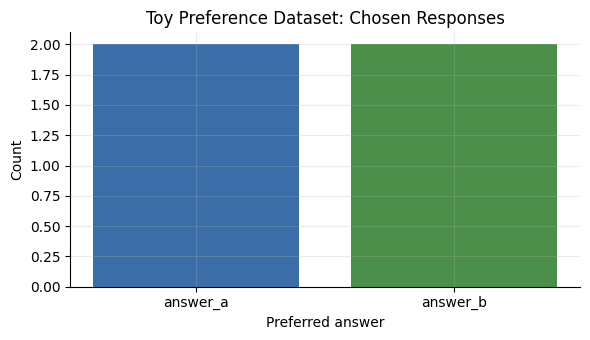

In [7]:
preferred_counts = preference_examples["preferred"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(preferred_counts.index, preferred_counts.values, color=["#3b6ea8", "#4b8f4b"])
ax.set_title("Toy Preference Dataset: Chosen Responses")
ax.set_xlabel("Preferred answer")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Reward Models

A reward model learns to score prompt-response pairs.

Input:

Prompt + Response → Reward Score

The score is not a truth label. It is a learned estimate of what humans are likely to prefer. RLHF uses this score to improve the model's behavior.

In [8]:
reward_rows = [
    {"prompt": "Explain overfitting.", "response": "Overfitting is memorizing training data.", "reward_score": 0.82},
    {"prompt": "Explain overfitting.", "response": "It is a highly technical manifold issue.", "reward_score": 0.34},
    {"prompt": "I clicked a suspicious link.", "response": "Change passwords and report it.", "reward_score": 0.88},
    {"prompt": "I clicked a suspicious link.", "response": "Do nothing.", "reward_score": 0.10},
]

reward_df = pd.DataFrame(reward_rows)
display(reward_df)

,prompt,response,reward_score
0,Explain overfitting.,Overfitting is memorizing training data.,0.82
1,Explain overfitting.,It is a highly technical manifold issue.,0.34
2,I clicked a suspicious link.,Change passwords and report it.,0.88
3,I clicked a suspicious link.,Do nothing.,0.10


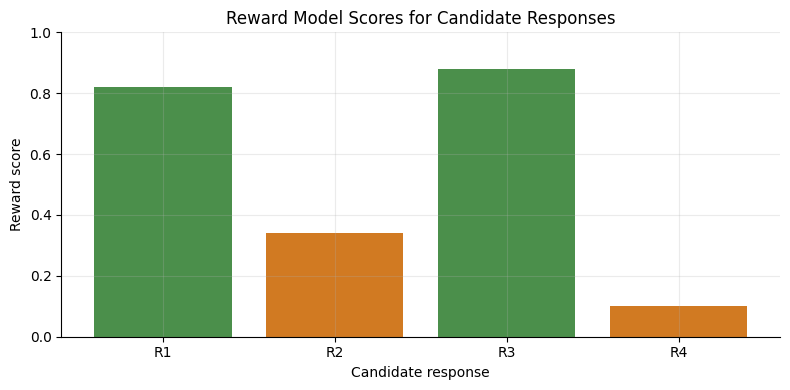

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = [f"R{i + 1}" for i in range(len(reward_df))]
colors = ["#4b8f4b" if score >= 0.7 else "#d17a22" for score in reward_df["reward_score"]]
ax.bar(labels, reward_df["reward_score"], color=colors)
ax.set_title("Reward Model Scores for Candidate Responses")
ax.set_xlabel("Candidate response")
ax.set_ylabel("Reward score")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Reinforcement Learning from Human Feedback (RLHF)

RLHF uses a reward model to improve a language model's policy.

A simplified workflow:

Prompt → LLM → Response → Reward Model → PPO → Updated Model

The reward model estimates response quality. PPO is then used to update the language model so it becomes more likely to produce high-reward responses.

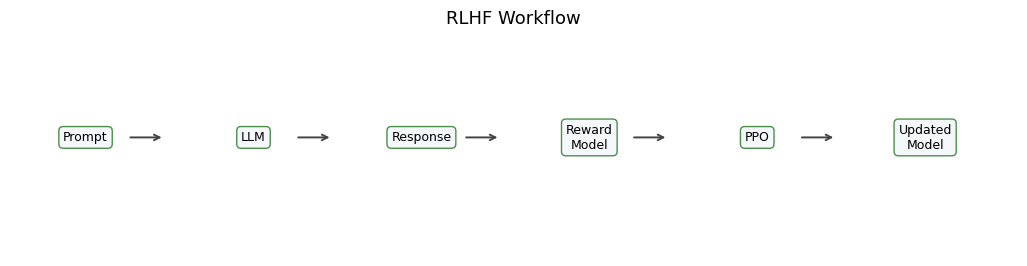

In [10]:
rlhf_steps = ["Prompt", "LLM", "Response", "Reward\nModel", "PPO", "Updated\nModel"]
draw_pipeline(rlhf_steps, "RLHF Workflow", color="#4b8f4b")

## PPO Intuition

PPO stands for Proximal Policy Optimization. You do not need deep reinforcement learning math to understand the basic idea.

- Policy: the model's current behavior
- Reward: a score for how good the output was
- Optimization: update the model to make better-scoring behavior more likely

PPO tries to improve the policy without changing it too aggressively in one step. That constraint matters because language models can become unstable if updates are too large.

In [11]:
ppo_intuition = pd.DataFrame({
    "concept": ["Policy", "Reward", "Optimization", "Constraint"],
    "plain meaning": [
        "the model's response behavior",
        "a score from the reward model",
        "make preferred behavior more likely",
        "avoid changing the model too drastically",
    ],
    "toy example": [
        "usually gives short answers",
        "higher score for clear and safe answer",
        "increase probability of clear answer style",
        "do not destroy grammar or task ability",
    ],
})

display(ppo_intuition)

,concept,plain meaning,toy example
0,Policy,the model's response behavior,usually gives short answers
1,Reward,a score from the reward model,higher score for clear and safe answer
2,Optimization,make preferred behavior more likely,increase probability of clear answer style
3,Constraint,avoid changing the model too drastically,do not destroy grammar or task ability


## Limitations of RLHF

RLHF is powerful, but it is operationally heavy.

Common limitations:

- expensive human data collection
- separate reward model training
- complex RL infrastructure
- unstable optimization
- reward hacking risk
- difficult debugging
- high compute and engineering cost

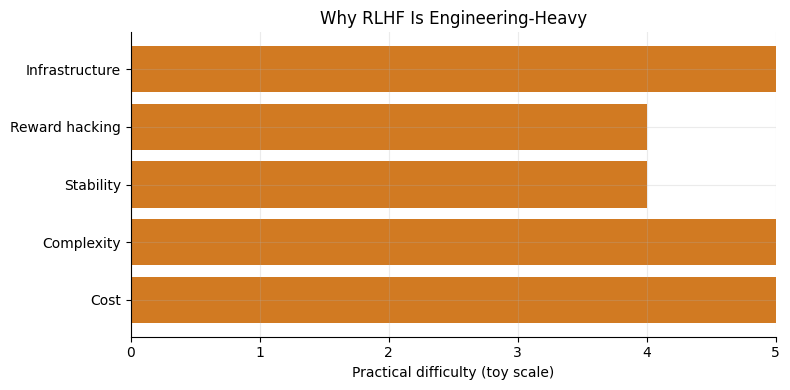

,limitation,severity_1_to_5
0,Cost,5
1,Complexity,5
2,Stability,4
3,Reward hacking,4
4,Infrastructure,5


In [12]:
rlhf_limitations = pd.DataFrame({
    "limitation": ["Cost", "Complexity", "Stability", "Reward hacking", "Infrastructure"],
    "severity_1_to_5": [5, 5, 4, 4, 5],
})

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(rlhf_limitations["limitation"], rlhf_limitations["severity_1_to_5"], color="#d17a22")
ax.set_title("Why RLHF Is Engineering-Heavy")
ax.set_xlabel("Practical difficulty (toy scale)")
ax.set_xlim(0, 5)
plt.tight_layout()
plt.show()

display(rlhf_limitations)

## Direct Preference Optimization (DPO)

DPO is the main idea in this notebook.

Instead of training a separate reward model and then running reinforcement learning, DPO directly learns from preference pairs:

Prompt + chosen response + rejected response

The model is optimized to assign higher likelihood to the chosen response than to the rejected response. This makes the workflow simpler and often more stable than RLHF.

## Why DPO Became Popular

DPO became popular because it fits naturally into standard supervised fine-tuning infrastructure.

It avoids several moving parts:

- no separate reward model
- no PPO loop
- less RL-specific infrastructure
- simpler training setup
- often easier reproducibility

The core intuition is straightforward: increase the model's preference for chosen responses and decrease its preference for rejected responses.

## RLHF vs DPO

Both RLHF and DPO use preference information. They differ in how that information updates the model.

In [13]:
rlhf_dpo_comparison = pd.DataFrame({
    "dimension": [
        "Complexity",
        "Training stability",
        "Infrastructure",
        "Reward model",
        "Implementation difficulty",
        "Popularity",
    ],
    "RLHF": [
        "high",
        "can be unstable",
        "RL pipeline with PPO",
        "required",
        "harder",
        "classic alignment approach",
    ],
    "DPO": [
        "lower",
        "often more stable",
        "similar to fine-tuning pipeline",
        "not required",
        "easier",
        "widely used for preference tuning",
    ],
})

display(rlhf_dpo_comparison)

,dimension,RLHF,DPO
0,Complexity,high,lower
1,Training stability,can be unstable,often more stable
2,Infrastructure,RL pipeline with PPO,similar to fine-tuning pipeline
3,Reward model,required,not required
4,Implementation difficulty,harder,easier
5,Popularity,classic alignment approach,widely used for preference tuning


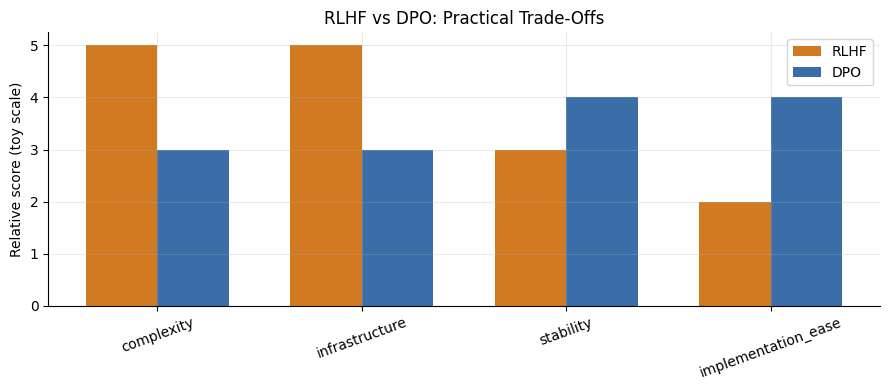

In [14]:
comparison_scores = pd.DataFrame({
    "method": ["RLHF", "DPO"],
    "complexity": [5, 3],
    "infrastructure": [5, 3],
    "stability": [3, 4],
    "implementation_ease": [2, 4],
})

metrics = ["complexity", "infrastructure", "stability", "implementation_ease"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width / 2, comparison_scores.loc[0, metrics], width, label="RLHF", color="#d17a22")
ax.bar(x + width / 2, comparison_scores.loc[1, metrics], width, label="DPO", color="#3b6ea8")
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=20)
ax.set_ylabel("Relative score (toy scale)")
ax.set_title("RLHF vs DPO: Practical Trade-Offs")
ax.legend()
plt.tight_layout()
plt.show()

## Toy Preference Dataset

The dataset below uses the structure commonly used in preference tuning:

- prompt
- chosen response
- rejected response

The chosen response is not perfect. It is simply better than the rejected response according to the preference label.

In [15]:
toy_preferences = pd.DataFrame({
    "prompt": [
        "How should I handle a failed production deployment?",
        "Explain why my model overfits.",
        "Write a response to an angry customer.",
        "What should I do after clicking a phishing link?",
        "Summarize a long incident report.",
        "How can I improve API latency?",
    ],
    "chosen_response": [
        "Pause rollout, inspect logs, communicate status, and rollback if user impact is growing.",
        "The model may be memorizing training data; try regularization, more data, or validation monitoring.",
        "Acknowledge the frustration, apologize clearly, and offer concrete next steps.",
        "Disconnect if needed, change passwords, enable MFA, and report the event to security.",
        "Identify timeline, impact, root cause, mitigation, and follow-up actions.",
        "Measure bottlenecks, cache common responses, optimize queries, and set clear latency budgets.",
    ],
    "rejected_response": [
        "Keep deploying and hope the issue resolves itself.",
        "Overfitting is impossible if the model is large enough.",
        "Tell the customer they are wrong and close the ticket.",
        "Ignore it because most links are harmless.",
        "Say that everything broke without details.",
        "Buy larger servers before measuring anything.",
    ],
})

display(toy_preferences)

,prompt,chosen_response,rejected_response
0,How should I handle a failed production deploy...,"Pause rollout, inspect logs, communicate statu...",Keep deploying and hope the issue resolves its...
1,Explain why my model overfits.,The model may be memorizing training data; try...,Overfitting is impossible if the model is larg...
2,Write a response to an angry customer.,"Acknowledge the frustration, apologize clearly...",Tell the customer they are wrong and close the...
3,What should I do after clicking a phishing link?,"Disconnect if needed, change passwords, enable...",Ignore it because most links are harmless.
4,Summarize a long incident report.,"Identify timeline, impact, root cause, mitigat...",Say that everything broke without details.
5,How can I improve API latency?,"Measure bottlenecks, cache common responses, o...",Buy larger servers before measuring anything.


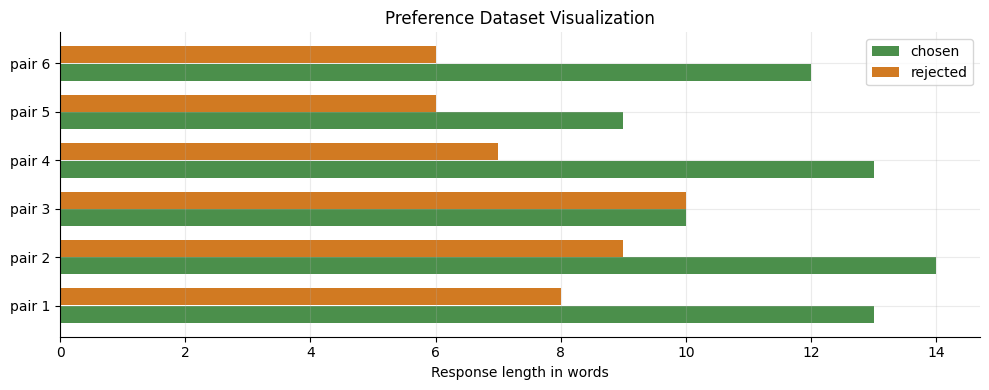

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
y_positions = np.arange(len(toy_preferences))
ax.barh(y_positions - 0.18, [len(text.split()) for text in toy_preferences["chosen_response"]], height=0.35, label="chosen", color="#4b8f4b")
ax.barh(y_positions + 0.18, [len(text.split()) for text in toy_preferences["rejected_response"]], height=0.35, label="rejected", color="#d17a22")
ax.set_yticks(y_positions)
ax.set_yticklabels([f"pair {i + 1}" for i in y_positions])
ax.set_xlabel("Response length in words")
ax.set_title("Preference Dataset Visualization")
ax.legend()
plt.tight_layout()
plt.show()

## Mini DPO Intuition

This section is not a full DPO implementation.

Instead, it demonstrates the core preference signal with NumPy: chosen responses should receive stronger positive optimization signals than rejected responses.

Think of each response as having a model score. Preference tuning tries to increase the margin between the chosen score and the rejected score.

In [17]:
quality_keywords = {
    "safe": ["rollback", "inspect", "communicate", "report", "mfa", "security", "measure", "monitoring"],
    "helpful": ["steps", "try", "identify", "optimize", "cache", "acknowledge", "offer", "mitigation"],
    "bad": ["hope", "ignore", "wrong", "impossible", "harmless", "broke", "larger"],
}


def simple_preference_score(text):
    """Compute a toy preference score based on helpful and unsafe keywords."""
    lower_text = text.lower()
    score = 0.0
    for word in quality_keywords["safe"]:
        score += 1.0 if word in lower_text else 0.0
    for word in quality_keywords["helpful"]:
        score += 0.7 if word in lower_text else 0.0
    for word in quality_keywords["bad"]:
        score -= 1.2 if word in lower_text else 0.0
    score += min(len(text.split()) / 20, 1.0) * 0.5
    return score


def preference_margin(chosen_score, rejected_score):
    """Return the score margin between chosen and rejected responses."""
    return chosen_score - rejected_score

score_rows = []
for idx, row in toy_preferences.iterrows():
    chosen_score = simple_preference_score(row["chosen_response"])
    rejected_score = simple_preference_score(row["rejected_response"])
    score_rows.append({
        "pair": idx + 1,
        "chosen_score": chosen_score,
        "rejected_score": rejected_score,
        "preference_margin": preference_margin(chosen_score, rejected_score),
    })

score_df = pd.DataFrame(score_rows)
display(score_df.round(3))

,pair,chosen_score,rejected_score,preference_margin
0,1,3.325,-1.000,4.325
1,2,2.050,-0.975,3.025
2,3,2.350,-0.950,3.300
3,4,3.325,-2.225,5.550
4,5,1.625,-1.050,2.675
5,6,2.700,-1.050,3.750


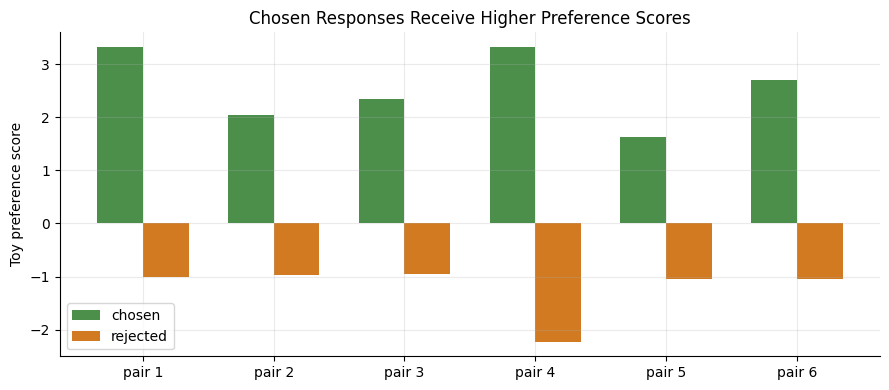

In [18]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(score_df))
width = 0.35
ax.bar(x - width / 2, score_df["chosen_score"], width, label="chosen", color="#4b8f4b")
ax.bar(x + width / 2, score_df["rejected_score"], width, label="rejected", color="#d17a22")
ax.set_xticks(x)
ax.set_xticklabels([f"pair {i}" for i in score_df["pair"]])
ax.set_ylabel("Toy preference score")
ax.set_title("Chosen Responses Receive Higher Preference Scores")
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
def sigmoid(x):
    """Compute sigmoid values."""
    return 1 / (1 + np.exp(-x))

score_df["preference_probability"] = sigmoid(score_df["preference_margin"])
score_df["optimization_signal"] = 1 - score_df["preference_probability"]

display(score_df[["pair", "preference_margin", "preference_probability", "optimization_signal"]].round(3))

,pair,preference_margin,preference_probability,optimization_signal
0,1,4.325,0.987,0.013
1,2,3.025,0.954,0.046
2,3,3.300,0.964,0.036
3,4,5.550,0.996,0.004
4,5,2.675,0.936,0.064
5,6,3.750,0.977,0.023


## Interpreting the Toy Optimization Signal

When the chosen response already scores much higher than the rejected response, the optimization signal is small.

When the margin is weak, the signal is larger. This mirrors the intuition behind preference optimization: the model should learn most from pairs where it does not yet strongly prefer the chosen response.

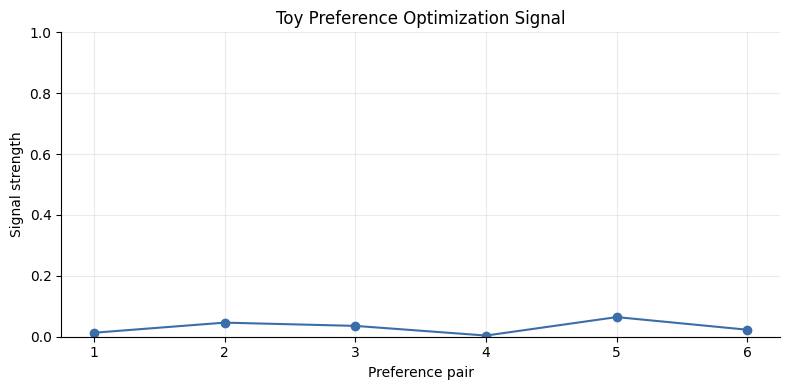

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(score_df["pair"], score_df["optimization_signal"], marker="o", color="#3b6ea8")
ax.set_title("Toy Preference Optimization Signal")
ax.set_xlabel("Preference pair")
ax.set_ylabel("Signal strength")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Alignment Failures

Alignment is difficult because human preferences are complex and context-dependent.

Common failure modes include:

- hallucinations
- bias
- unsafe outputs
- refusal failures
- prompt injection
- over-refusal
- reward hacking

A model can appear aligned in simple tests and still fail in edge cases.

In [21]:
failure_modes = pd.DataFrame({
    "failure mode": ["Hallucination", "Bias", "Unsafe output", "Refusal failure", "Prompt injection"],
    "what happens": [
        "model invents unsupported facts",
        "model treats groups or viewpoints unfairly",
        "model gives harmful instructions",
        "model refuses safe requests or answers unsafe ones",
        "model follows malicious instructions hidden in input",
    ],
    "why hard": [
        "confidence is not truth",
        "preferences vary and data may be biased",
        "safety depends on context",
        "boundaries are subtle",
        "inputs can attack the instruction hierarchy",
    ],
})

display(failure_modes)

,failure mode,what happens,why hard
0,Hallucination,model invents unsupported facts,confidence is not truth
1,Bias,model treats groups or viewpoints unfairly,preferences vary and data may be biased
2,Unsafe output,model gives harmful instructions,safety depends on context
3,Refusal failure,model refuses safe requests or answers unsafe ...,boundaries are subtle
4,Prompt injection,model follows malicious instructions hidden in...,inputs can attack the instruction hierarchy


## Modern Alignment Techniques

Modern alignment is a family of methods, not a single algorithm.

- RLHF: trains a reward model, then optimizes the model with reinforcement learning.
- DPO: directly optimizes preference pairs without a separate reward model.
- ORPO: combines supervised fine-tuning and preference optimization ideas.
- IPO: another preference optimization objective designed for stable learning.
- RLAIF: uses AI feedback instead of, or alongside, human feedback.

The shared goal is to make model behavior better match desired preferences.

In [22]:
techniques_df = pd.DataFrame({
    "technique": ["RLHF", "DPO", "ORPO", "IPO", "RLAIF"],
    "short description": [
        "reward model plus RL optimization",
        "direct learning from chosen/rejected pairs",
        "preference optimization combined with SFT-style training",
        "stable preference optimization objective",
        "alignment using AI-generated feedback",
    ],
    "main appeal": [
        "powerful and historically important",
        "simpler preference tuning workflow",
        "efficient training recipe",
        "stability-focused objective",
        "scales feedback collection",
    ],
})

display(techniques_df)

,technique,short description,main appeal
0,RLHF,reward model plus RL optimization,powerful and historically important
1,DPO,direct learning from chosen/rejected pairs,simpler preference tuning workflow
2,ORPO,preference optimization combined with SFT-styl...,efficient training recipe
3,IPO,stable preference optimization objective,stability-focused objective
4,RLAIF,alignment using AI-generated feedback,scales feedback collection


## Alignment in Real Models

Modern assistants such as ChatGPT, Claude, Gemini, Llama, Mistral, and DeepSeek rely on alignment stages after pretraining.

Exact training recipes vary by organization and model family, but the pattern is consistent: pretraining gives broad language ability, while instruction tuning and preference optimization make the model more useful as an assistant.

This notebook does not compare benchmark scores. The goal is to understand the alignment workflow.

## Practical Workflow

A practical model development process continues after alignment. Teams collect feedback, evaluate behavior, and monitor deployed systems.

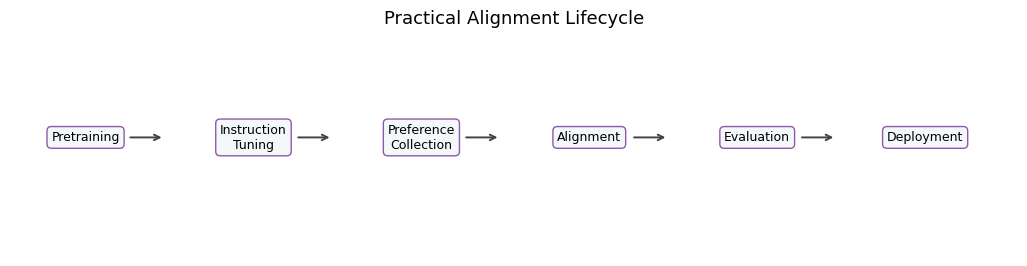

In [23]:
alignment_lifecycle = [
    "Pretraining",
    "Instruction\nTuning",
    "Preference\nCollection",
    "Alignment",
    "Evaluation",
    "Deployment",
]

draw_pipeline(alignment_lifecycle, "Practical Alignment Lifecycle", color="#8d5aa7")

## Mini Project: Tiny Preference Comparison Tool

The tool below compares two candidate responses for a prompt using a transparent toy scoring function.

This is not a real reward model. It is a small educational tool for understanding how preference signals can be represented and visualized.

In [24]:
def compare_responses(prompt, response_a, response_b):
    """Compare two candidate responses with a toy preference score."""
    score_a = simple_preference_score(response_a)
    score_b = simple_preference_score(response_b)
    preferred = "A" if score_a >= score_b else "B"
    return {
        "prompt": prompt,
        "response_a": response_a,
        "response_b": response_b,
        "score_a": score_a,
        "score_b": score_b,
        "preferred_response": preferred,
    }

comparison = compare_responses(
    prompt="What should I do during a production outage?",
    response_a="Inspect logs, communicate status, mitigate impact, and rollback if needed.",
    response_b="Ignore alerts and wait until users stop complaining.",
)

display(pd.DataFrame([comparison]))

,prompt,response_a,response_b,score_a,score_b,preferred_response
0,What should I do during a production outage?,"Inspect logs, communicate status, mitigate imp...",Ignore alerts and wait until users stop compla...,3.25,-1.0,A


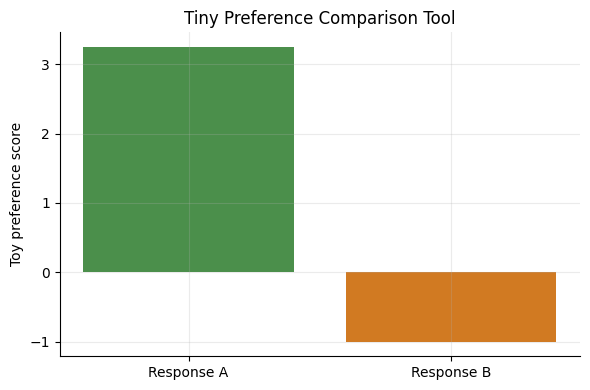

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Response A", "Response B"], [comparison["score_a"], comparison["score_b"]], color=["#4b8f4b", "#d17a22"])
ax.set_title("Tiny Preference Comparison Tool")
ax.set_ylabel("Toy preference score")
plt.tight_layout()
plt.show()

## Advantages of Alignment

Alignment improves the user-facing behavior of a model.

Benefits include:

- better user experience
- more helpful responses
- safer behavior
- fewer harmful outputs
- clearer refusals
- better instruction following
- more appropriate tone

## Limitations of Alignment

Alignment is not a complete solution.

Limitations include:

- expensive data collection
- disagreement among human labelers
- cultural and contextual bias
- reward hacking
- evaluation difficulty
- safety failures in unusual situations
- trade-offs between helpfulness and refusal behavior

## Deployment Pipeline

After alignment, the model still needs production serving and monitoring.

A simplified deployment path is:

Aligned Model → Safety Evaluation → Serving Stack → Monitoring → Feedback Loop

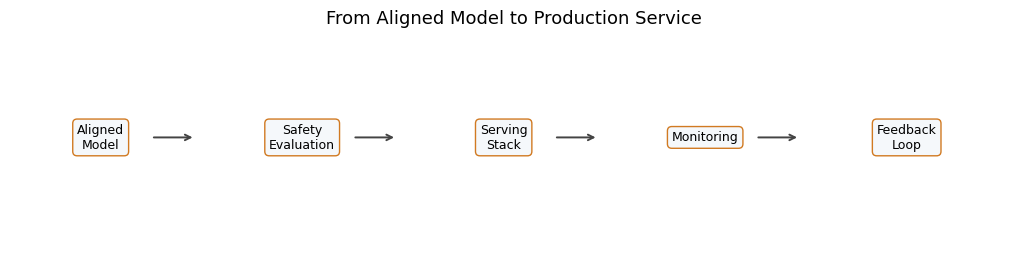

In [26]:
deployment_steps = [
    "Aligned\nModel",
    "Safety\nEvaluation",
    "Serving\nStack",
    "Monitoring",
    "Feedback\nLoop",
]

draw_pipeline(deployment_steps, "From Aligned Model to Production Service", color="#d17a22")

## Final Summary

Key takeaways:

- SFT teaches a model to follow demonstrations.
- Reward models estimate which responses humans prefer.
- RLHF uses a reward model and reinforcement learning to improve behavior.
- DPO directly learns from chosen/rejected response pairs.
- Modern alignment combines preference data, safety evaluation, and deployment feedback.
- Alignment is one of the defining innovations behind modern conversational LLMs.

## Next Notebook

➡️ Next: LLM Serving & Inference

After building and aligning a model, the next step is deploying it as a scalable production service.